**binary classification**

one thing or another.(e.g. spam or not spam)

**multiclass classification**

more than one thing or another(e.g. Is this a photo of sushi, steak or pizza?)

**multilabel classification**

multiple label options per sample

In [2]:
import torch
from torch import nn # nn contains all of PyTorch's buidling blocks for neural networks
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import pandas as pd
import requests
from pathlib import Path

# neural network classification with PyTorch

classification is a problem of predicting whether something is one thing or another (there can be multiple things as the options).

In [3]:
# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [4]:
len(X), len(y)

(1000, 1000)

In [5]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples of y: {y[:5]}")

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: [1 1 1 1 0]


In [6]:
# Make DataFrame of circle data
circles = pd.DataFrame({"X1": X[:, 0], 
                        "X2": X[:, 1],
                        "label":y 
                        })
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


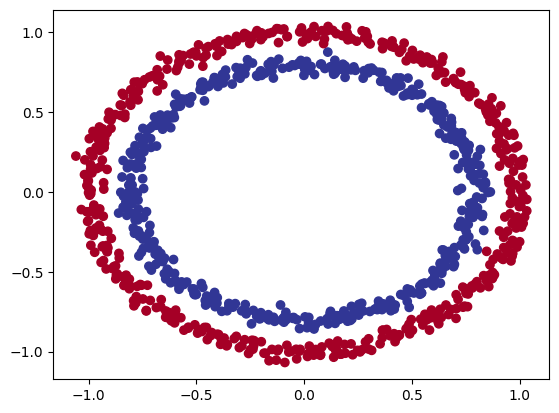

In [7]:
# Visualize
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)

**note**: The data we're working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

# check input and output shapes

In [8]:
X.shape, y.shape

((1000, 2), (1000,))

In [9]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [10]:
# view the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of x: {X_sample} and the same fot y: {y_sample}")
print(f"Shapes for one sample of x: {X_sample.shape} and the same fot y: {y_sample.shape}")

Values for one sample of x: [0.75424625 0.23148074] and the same fot y: 1
Shapes for one sample of x: (2,) and the same fot y: ()


# turn data into tensors and create train and test splits

In [11]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [12]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

type(X), X[:5], y[:5]

(torch.Tensor,
 tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [13]:
torch.manual_seed(42)

In [14]:
# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

# Building a model

1. let's build a model to classify our blue and red dots.

To do so, we want to :
1. setup device agonistic code so our code will run on a accelerator(GPU) if there is one
2. construct a model(nn.Module)
3. define a loss function and optimizer
4. create a training and test loop

In [15]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [16]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Now we've setup device agnostic code, let's create a model that:
1. Subclasses nn.Module (almost all models in PyTorch subclass nn.Module)
2. Create 2 nn.Linear() layers that are capable of handling the shapes of our data
3. Defines a forward() method that outlines the forward pass (or forward computation) of a model
4. instatiate an instance of our model class and send it to the target device


In [17]:
X_train.shape

torch.Size([800, 2])

In [18]:
y_train[:5]

tensor([1., 0., 0., 0., 1.])

In [19]:
# Construc a model that subclasses nn.Module

class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # create 2 nn.Linear layers capable of handling the shapes of our data
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features and upscales to 5 features 
        self.layer_2 = nn.Linear(in_features=2, out_features=1) # takes in 5 features from previous layer and outputs a single feature (same shape as y)
      
    # define a forward() method that outlines the forward pass  
    def forward(self, x):
        return self.layer_2(self.layer_1(x))    # x -> layer_1 -> layer_2 -> output
    
# instantiate an instance of our model class and send it to the targer device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=2, out_features=1, bias=True)
)

In [20]:
device

'cpu'

In [21]:
next(model_0.parameters()).device

device(type='cpu')

In [22]:
# let's replicate the model above using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [23]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.3301,  0.1802],
                      [-0.3258, -0.0829],
                      [-0.2872,  0.4691],
                      [-0.5582, -0.3260],
                      [-0.1997, -0.4252]])),
             ('0.bias', tensor([ 0.0667, -0.6984,  0.6386, -0.6007,  0.5459])),
             ('1.weight',
              tensor([[ 0.0744, -0.1452,  0.2764,  0.0697,  0.3613]])),
             ('1.bias', tensor([0.0489]))])

In [24]:
# make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\n Fitst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

 Fitst 10 predictions:
tensor([[0.5355],
        [0.4642],
        [0.6117],
        [0.5144],
        [0.4355],
        [0.3933],
        [0.3319],
        [0.3149],
        [0.6190],
        [0.4574]])

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [25]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.3301,  0.1802],
                      [-0.3258, -0.0829],
                      [-0.2872,  0.4691],
                      [-0.5582, -0.3260],
                      [-0.1997, -0.4252]])),
             ('0.bias', tensor([ 0.0667, -0.6984,  0.6386, -0.6007,  0.5459])),
             ('1.weight',
              tensor([[ 0.0744, -0.1452,  0.2764,  0.0697,  0.3613]])),
             ('1.bias', tensor([0.0489]))])

In [26]:
# setup loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss() # sigmoid activision function built-in
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [27]:
# calculate accuracy - out of 100 examples, what percentage does our model get right
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    
    return acc

# train model

To train our model, we are going to need to build a training loop with the following steps:

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (Backpropagation)
5. Optimizer (gradient descent)


`Going from raw logits -> prediction probabilites -> prediction labels`

Our model outputs are going to be raw **logits**.

We can convert these **logits** into **prediction probabilities** by passing them to some kind of activision function(e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabilities to **prediction labels** by either rounding them or taking the argmax()

In [28]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]

y_logits

tensor([[0.5355],
        [0.4642],
        [0.6117],
        [0.5144],
        [0.4355]])

In [29]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [30]:
# use the sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.6308],
        [0.6140],
        [0.6483],
        [0.6258],
        [0.6072]])

For our prediction probability values, we need to perform a range-style rounding on them:
* `y_pred_probs` >=0.5, y=1 (class 1)
* `y_pred_probs` < 0.5, y=0 (class 0)

In [31]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# Pred probs" is short for predicted probabilities in machine learning and statistics
# in full (logits -> pred probs -> pred labels)
y_pred_lables = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# check for eqaulity
print(torch.eq(y_preds.squeeze(), y_pred_lables.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([1., 1., 1., 1., 1.])

In [32]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

# Building a training and testing loop



In [33]:
torch.manual_seed(42)

# set the number of epoch
epochs = 100

# put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    # training
    model_0.train()

    # Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -< pred labels

    # calculate loss/accuracy
    loss = loss_fn(y_logits, y_train) # bb.BCEWithLogistsLoss expects raw logits as input
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # optimizer zero grad
    optimizer.zero_grad()

    # loss bacward (backpropagation)
    loss.backward()
    
    # Optimizer step (gradient descent)
    optimizer.step()

    # Testing
    model_0.eval()
    with torch.inference_mode():
        # forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # calcualte test loss/acc
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

        # print out what's happening
        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:2f}% | Test loss: {test_loss:.5f}, Test_acc: {test_acc:.2f}% ")

Epoch: 0 | Loss: 0.72448, Acc: 50.000000% | Test loss: 0.71762, Test_acc: 50.00% 
Epoch: 10 | Loss: 0.70319, Acc: 50.000000% | Test loss: 0.69865, Test_acc: 50.00% 
Epoch: 20 | Loss: 0.69765, Acc: 56.125000% | Test loss: 0.69378, Test_acc: 58.00% 
Epoch: 30 | Loss: 0.69597, Acc: 52.500000% | Test loss: 0.69246, Test_acc: 50.50% 
Epoch: 40 | Loss: 0.69530, Acc: 51.625000% | Test loss: 0.69208, Test_acc: 51.50% 
Epoch: 50 | Loss: 0.69492, Acc: 51.000000% | Test loss: 0.69199, Test_acc: 50.00% 
Epoch: 60 | Loss: 0.69466, Acc: 50.750000% | Test loss: 0.69200, Test_acc: 50.50% 
Epoch: 70 | Loss: 0.69444, Acc: 50.500000% | Test loss: 0.69205, Test_acc: 50.50% 
Epoch: 80 | Loss: 0.69426, Acc: 50.625000% | Test loss: 0.69211, Test_acc: 50.00% 
Epoch: 90 | Loss: 0.69410, Acc: 50.625000% | Test loss: 0.69218, Test_acc: 49.50% 


# Make predictions and evaluate the model

From the metrics it looks like our model isn't learning anything...

so to inspect it let's make some predcitions and make them visual!

In other words, Visualize

To do som we're going to import a function called plot_decision_boundty()

In [34]:
# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


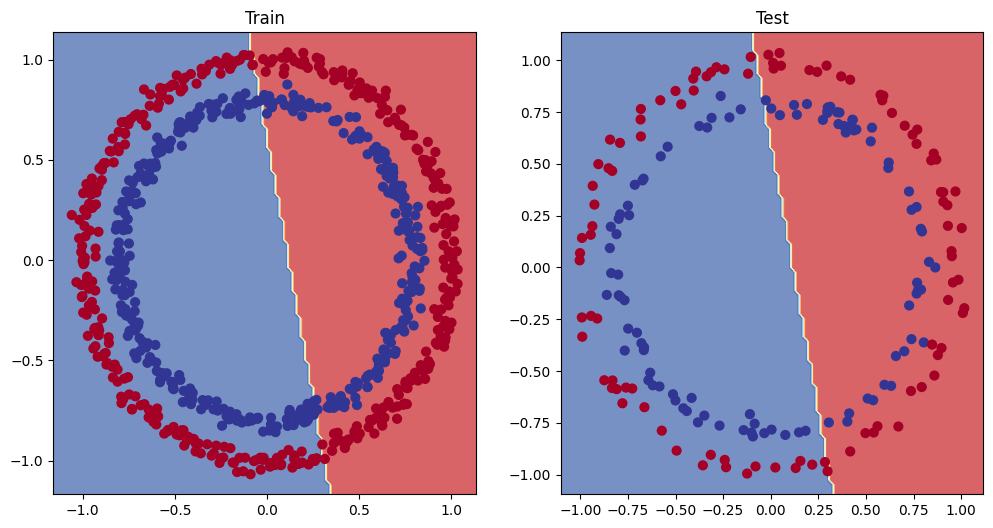

In [40]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [ ]:
10:58